In [4]:
import pandas as pd

df_pivot_top = pd.read_csv('1000s_top_pivot_nmf_7312x23.csv',index_col=0)
df_pivot_btm = pd.read_csv('1000s_btm_pivot_nmf_5515x21.csv',index_col=0)

In [8]:
from scipy.cluster.hierarchy import linkage, leaves_list
import numpy as np

NMFs = ['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5', 'NMF6', 'NMF7']
df_all = pd.DataFrame(columns=NMFs)
class_list = np.array(['Class'])
for cls in df_pivot_top.Class.unique():
    df_class = df_pivot_top.loc[df_pivot_top.Class==cls,:]
    df_class = df_class.loc[df_pivot_top[NMFs].max(axis=1)>0.5,NMFs]
    if df_class.shape[0]>2:
        Z = linkage(df_class, method='ward', metric='euclidean', optimal_ordering=True)
        df_all = pd.concat([df_all,df_class.iloc[leaves_list(Z),:]])
        class_list = np.append(class_list, np.repeat(cls, df_class.shape[0]))
    print(df_all.shape)
    print(len(class_list))

(1729, 7)
1730
(2144, 7)
2145
(2278, 7)
2279
(2313, 7)
2314
(2319, 7)
2320
(3371, 7)
3372
(3374, 7)
3375
(3417, 7)
3418
(3417, 7)
3418


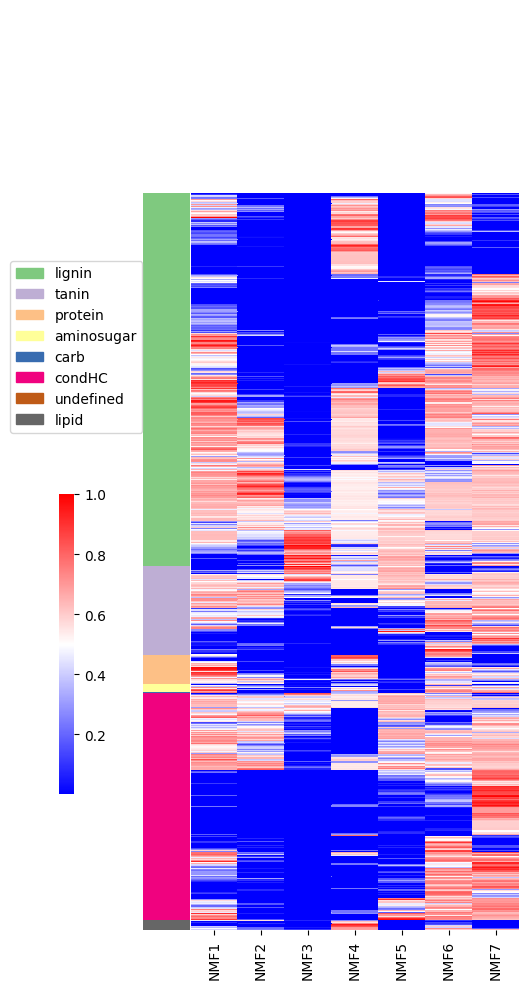

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
colors = plt.get_cmap('Accent').colors
sp_s = class_list[1:]
lut_s = dict(zip(pd.Series(sp_s).unique(), colors))
rowc_s = pd.Series(sp_s).map(lut_s).to_numpy()

g = sns.clustermap(df_all, figsize=(5,10),colors_ratio=0.1, xticklabels = NMFs,yticklabels=False, cmap="bwr",col_cluster=False, row_cluster=False, row_colors=rowc_s, cbar_pos=(0.05, .2, .03, .3))
#g.ax_col_dendrogram.legend(loc="upper left", bbox_to_anchor=(0.5, 1.15))
handles = [plt.Rectangle((0,0),1,1, color=lut_s[label]) for label in lut_s]
plt.legend(handles, lut_s.keys(),loc="upper right", bbox_to_anchor=(6, 1.8), ncol=1)

In [10]:
NMFs = ['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5']
df_all = pd.DataFrame(columns=NMFs)
class_list = np.array(['Class'])
for cls in df_pivot_btm.Class.unique():
    df_class = df_pivot_btm.loc[df_pivot_btm.Class==cls,:]
    df_class = df_class.loc[df_pivot_btm[NMFs].max(axis=1)>0.5,NMFs]
    if df_class.shape[0]>2:
        Z = linkage(df_class, method='ward', metric='euclidean', optimal_ordering=True)
        df_all = pd.concat([df_all,df_class.iloc[leaves_list(Z),:]])
        class_list = np.append(class_list, np.repeat(cls, df_class.shape[0]))
    print(df_all.shape)
    print(len(class_list))

(1151, 5)
1152
(1513, 5)
1514
(1527, 5)
1528
(1571, 5)
1572
(1571, 5)
1572
(2214, 5)
2215
(2214, 5)
2215
(2220, 5)
2221
(2220, 5)
2221


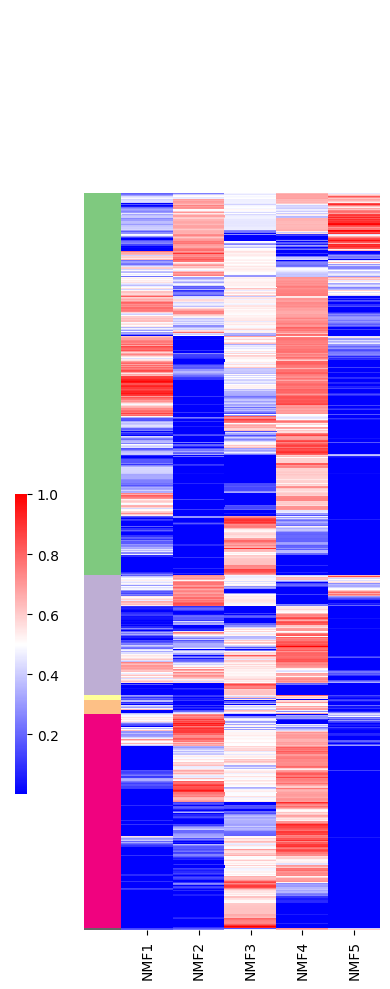

In [11]:
sp_s = class_list[1:]
rowc_s = pd.Series(sp_s).map(lut_s).to_numpy()

g = sns.clustermap(df_all, figsize=(4,10),colors_ratio=0.1, xticklabels = NMFs,yticklabels=False, cmap="bwr",col_cluster=False, row_cluster=False, row_colors=rowc_s, cbar_pos=(0.05, .2, .03, .3))

In [15]:
df_env_top = pd.read_csv('1000s_top_env_resp_kmeans_nmf.csv', index_col=0)
df_env_btm = pd.read_csv('1000s_btm_env_resp_kmeans_nmf.csv', index_col=0)

In [22]:
NMFs = ['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5', 'NMF6', 'NMF7']
nmf_w_low = df_env_top.loc[df_env_top['Kmeans']==0,NMFs].sum()
nmf_w_med = df_env_top.loc[df_env_top['Kmeans']==1,NMFs].sum()
nmf_w_high = df_env_top.loc[df_env_top['Kmeans']==2,NMFs].sum()

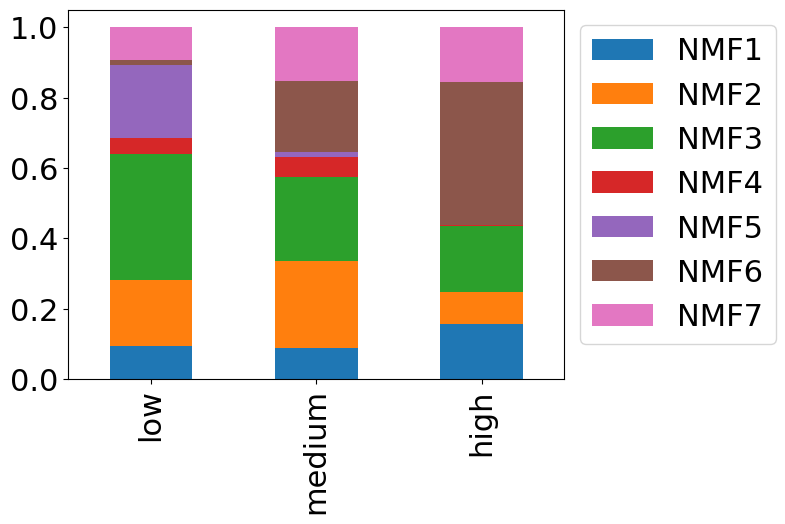

In [24]:
import matplotlib
matplotlib.rcParams.update({'font.size': 22})

df_nmf_resp = pd.DataFrame(np.array([nmf_w_low,nmf_w_med, nmf_w_high]), columns=NMFs)
df_nmf_resp.index = ['low', 'medium', 'high']
# normalize by sum of each respiration level
df_nmf_resp = df_nmf_resp.transpose()/df_nmf_resp.sum(axis=1)
axes = df_nmf_resp.transpose().plot(kind='bar', stacked=True)
axes.legend(bbox_to_anchor= (1, 1)) 

In [25]:
NMFs = ['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5']
nmf_w_low = df_env_btm.loc[df_env_btm['Kmeans']==0,NMFs].sum()
nmf_w_med = df_env_btm.loc[df_env_btm['Kmeans']==1,NMFs].sum()
nmf_w_high = df_env_btm.loc[df_env_btm['Kmeans']==2,NMFs].sum()

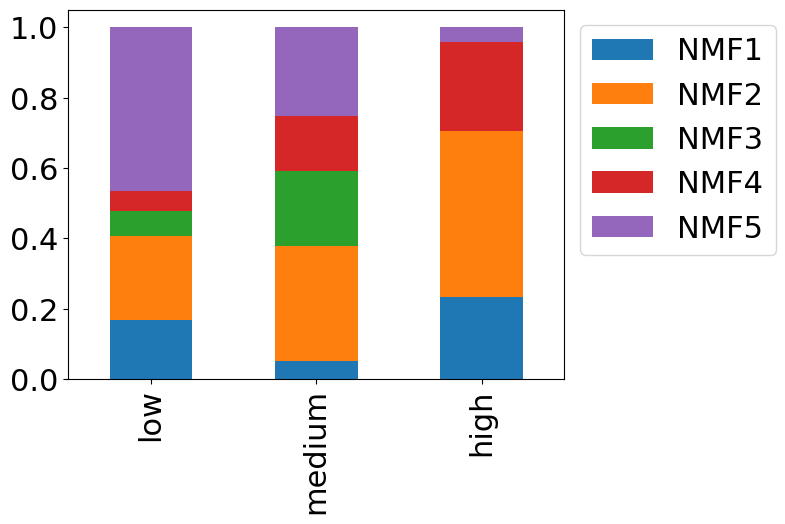

In [26]:
df_nmf_resp_btm = pd.DataFrame(np.array([nmf_w_low,nmf_w_med, nmf_w_high]), columns=NMFs)
df_nmf_resp_btm.index = ['low', 'medium', 'high']
df_nmf_resp_btm = df_nmf_resp_btm.transpose()/df_nmf_resp_btm.sum(axis=1)
axes = df_nmf_resp_btm.transpose().plot(kind='bar', stacked=True)
axes.legend(bbox_to_anchor= (1, 1)) 